<a href="https://colab.research.google.com/github/Juan-Medinaa/talento_tech/blob/main/conexion/Copia_de_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cuaderno de Regresión

Con este cuaderno se estudiarán métodos de regresión empleando diferentes técnicas para calcular la regresión. También se eplearán modelos pre existentes en la librería scikit-learn
para analizar el dataset ice_cream_revenue

## Sección 1: Uso del algoritmo de mínimos cuadrados para encontrar un modelo
En la primera sección se emplearán modelos de regresión encontrados con el método de mínimos cuadrados que se basa en encontrar la solución óptima para un problema de la forma
$$ Ax=b $$ y puede ser resuelto con álgebra lineal.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


### 1.1 Modelo lineal
Se trabajará con datos artificialmente generados. Creamos datos basados en la ecuación de una línea recta, luego agregamos ruido y graficamos los datos para tener una visualización de su comportamiento
El ruido que se agrega es de naturaleza Gaussiana, con media cero y desviación estándar de 0.75. Se crean 100 datos para efectos de una visualización adecuada

Text(0.5, 1.0, 'Dataset generado')

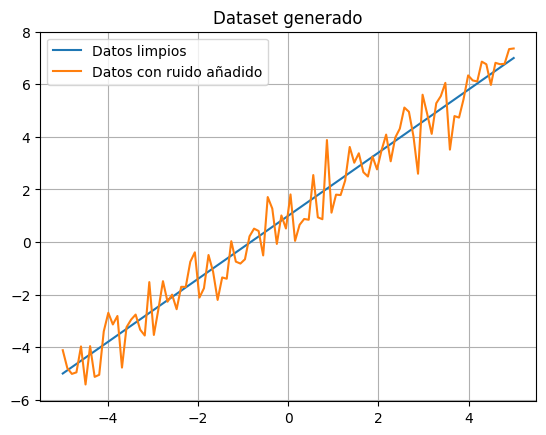

In [ ]:
datos_x = np.linspace(-5, 5, 100) # 100 datos del 0 al 20
pendiente = 1.2
intersecto = 1
datos_y = datos_x * pendiente + intersecto

# agregar ruido a los datos
datos_y_ruido = np.random.normal(0,0.75,100) + datos_y
plt.plot(datos_x, datos_y)
plt.plot(datos_x, datos_y_ruido)
plt.legend(["Datos limpios", "Datos con ruido añadido"])
plt.grid()
plt.title("Dataset generado")

### 1.2 Creación del modelo
posteriormente se crea el modelo y las matrices para resolver el problema de optimización de la forma
$$
A\times x = b
$$

En donde, en la matriz $A$ se colocan los valores independientes (x) y una columna de unos para multiplicar la matriz de parámetros ( a encontrar) $b$. La solución del sistema se puede hallar con la pseudo inversa de Moore penrose, disponible en `numpy.linalg.pinv()`


In [ ]:
A = np.array([datos_x, np.ones(len(datos_x))]).T
b = datos_y_ruido
parametros_b = np.linalg.pinv(A).dot(b)
print("Los parametros son: ", parametros_b)

Los parametros son:  [1.20656398 0.96480677]


Text(0.5, 1.0, 'Modelo de regresión lineal')

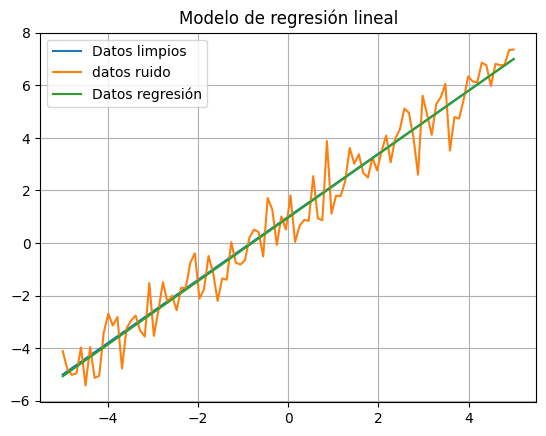

In [ ]:
# A partir de los datos con ruido se puede crear un nuevo modelo que se ajuste minimizando el error cuadrático
plt.plot(datos_x, datos_y)
plt.plot(datos_x, datos_y_ruido)
plt.plot(datos_x, datos_x*parametros_b[0]+parametros_b[1])
plt.legend(["Datos limpios","datos ruido", "Datos regresión"])
plt.grid()
plt.title("Modelo de regresión lineal")

## Sección 2: Análisis y  Regresión del dataset Ice-cream-revenue
### 2.1 Análisis exploratorio de los datos

Se empleará el dataset ice-cream-revenue que tiene las columnas de temperatura y cantidad vendida de helados. Utilizando scikit-learn se crearán modelos de regresión. El dataset se preprocesará para poder tener datos de evaluación del modelo


In [ ]:
import pandas as pd
import sklearn
import seaborn as sns


In [ ]:
df_helados = pd.read_csv("IceCreamData.csv")
df_helados.head()

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


In [ ]:
df_helados.info
df_helados.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [ ]:
df_helados.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


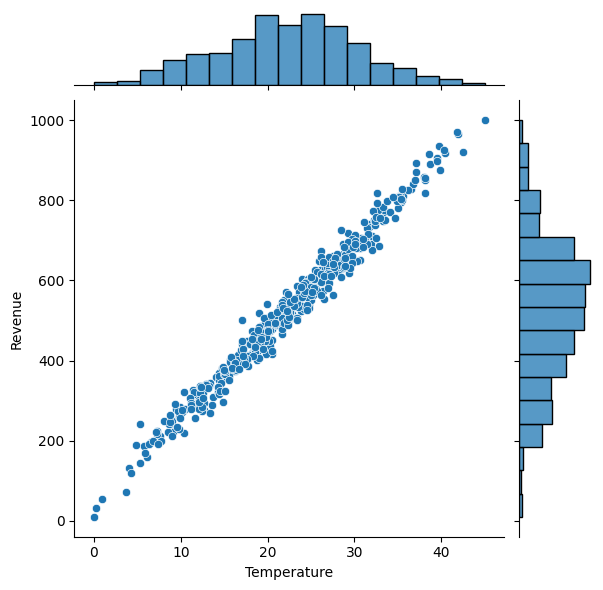

In [ ]:
sns.jointplot(x="Temperature", y="Revenue", data=df_helados)

### 2.2 Preparando los datos
Particionando el dataset para la creación de modelos. Esto mediante la función `train_test_split` de scikit-learn


In [ ]:
from sklearn.model_selection import train_test_split

# extrayendo la información del dataset
X = df_helados[["Temperature"]]
y = df_helados["Revenue"]

# particionando en dos conjuntos _train y _test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
print(X_train.shape)

(375, 1)


### 2.3 modelo de regresión lineal
Emplearemos el modelo `LinearRegression` de scikit-learn para ajustar los datos

In [ ]:
from sklearn.linear_model import LinearRegression

# crear el modelo
regressor = LinearRegression(fit_intercept = True)
# entrenarlo con los datos
regressor.fit(X_train, y_train)

# el modelo tendrá dos parámetros (A y B fueron llamados en el documento)
# se pueden mostrar con la función print
print(f"La pendiente del modelo (B) es: {regressor.coef_}, el intersecto (A) es {regressor.intercept_}")


La pendiente del modelo (B) es: [21.40042161], el intersecto (A) es 45.83139902180386


### 2.4 Evaluación del modelo

Text(0.5, 1.0, 'Ingresos por ventas de helados respecto a la temperatura')

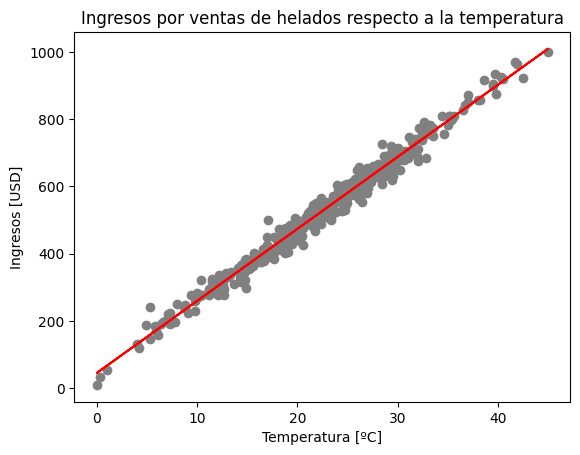

In [ ]:
y_pred = regressor.predict(X_test)
plt.scatter(X_train, y_train, color = 'gray')
plt.plot(X_train, regressor.predict(X_train), color = 'red')
plt.ylabel('Ingresos [USD]')
plt.xlabel('Temperatura [ºC]')
plt.title('Ingresos por ventas de helados respecto a la temperatura')

Text(0.5, 1.0, 'Ingresos por ventas de helados respecto a la temperatura (test data)')

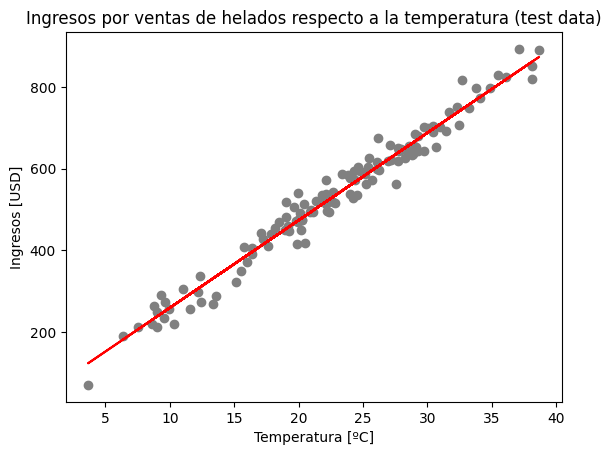

In [ ]:
# VISUALIZE TEST SET RESULTS
plt.scatter(X_test, y_test, color = 'gray')
plt.plot(X_test, regressor.predict(X_test), color = 'red')
plt.ylabel('Ingresos [USD]')
plt.xlabel('Temperatura [ºC]')
plt.title('Ingresos por ventas de helados respecto a la temperatura (test data)')



### Error medio cuadrático
Es una de las medidas más empleadas como función de pérdida en los algoritmos de regresión. Mide la distancia cuadrática entre una predicción del modelo respecto al dato correspondiente en el conjunto de datos para todos los puntos que tenga el conjunto de datos. Luego calcula el promedio de esas distancias.



In [ ]:
# evaluando el comportamiento del modelo
from sklearn.metrics import mean_squared_error
print("Mean Squared Error:",mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:",np.sqrt(mean_squared_error(y_test, y_pred)))



Mean Squared Error: 801.8321104153052
Root Mean Squared Error: 28.31664016819978


# Error medio absoluto
Es la diferencia entre los valores estimados y los reales. Se calcula el promedio de todas las diferencias para encontrar el valor del error


## Tarea:

Error cuadratico medio == mse (mean squared error)

```
# Error medio absoluto == mae (mean_absolute_error)

absolute = abs() en Python

| x | = +x, si x>=0
| x | = -x, si x<=0

Ejemplo:
| (5) | = +(5) = +5 = 5
| (-5) | = -(-5) = +5 = 5

15 = | 40 - 25 | = | 15 | = 15
15 = | 25 - 40 | = | -15 | = -(-15)= 15

def get_mean_absolute_error(y_real, y_pred):
  mae = | (y_real) - (y_pred) |
  # mae = | (y_pred) - (y_real) |
  return mae
```



In [ ]:
from sklearn.metrics import mean_absolute_error
# Recalculate y_pred for the linear regression model to match y_test
y_pred_linear = regressor.predict(X_test)
print("Mean Absolute Error:",mean_absolute_error(y_test, y_pred_linear))

Mean Absolute Error: 22.164244848667803


### R cuadrado
Es una medida estadística que indica que tan cerca estan los datos de ajustarse a una línea recta. Se conoce también como el coeficiente de determinación.

In [ ]:
from sklearn.metrics import r2_score
print("R^2:",r2_score(y_test, y_pred_linear))

R^2: 0.971032498303258


# Sección 3: regresión polinómica

Se crearán datos sintéticos para realizar la regrresión a un polinomio.


Text(0.5, 1.0, 'Dataset generado')

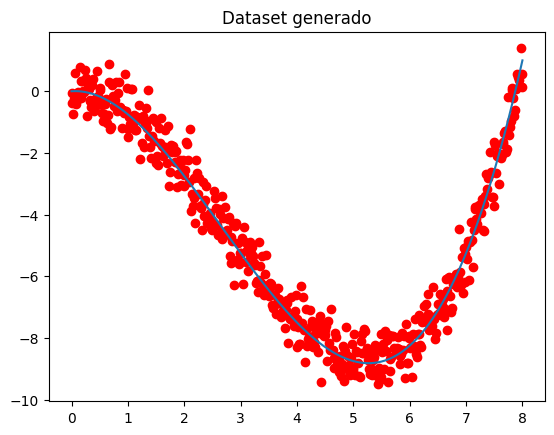

In [ ]:
x_data = np.linspace(0,8,500) # datos en X
y_data = 0.125*x_data**3 - x_data**2 + 0.125*x_data  # polinomio con los datos (cúbico)
y_data2 = np.random.normal(0,0.50,500) + y_data
plt.scatter(x_data, y_data2, c='r', )
plt.plot(x_data, y_data) # graficar los datos
plt.title("Dataset generado")

Para la regresión con un polinomio, se necesita preprocesar los datos `x_data` para que modelen un polinomio del grado indicado. Esto es, crear la matriz A para resolver el problema de la forma $Ax = b$, las dimensiones de la matriz A son de $m\times m$ siendo m el grado del polinomio

**Ejercicio**: Variar el grado del polinomio. Los datos corresponden a un polinomio de tercer grado, Se puede apreciar que con grados inferiores los datos van a tener un mal ajuste y con grados superiores puede existir sobre entrenamiento, por ejemplo de grado 20 se empiezan a notar problemas de ajuste

In [ ]:
n=20

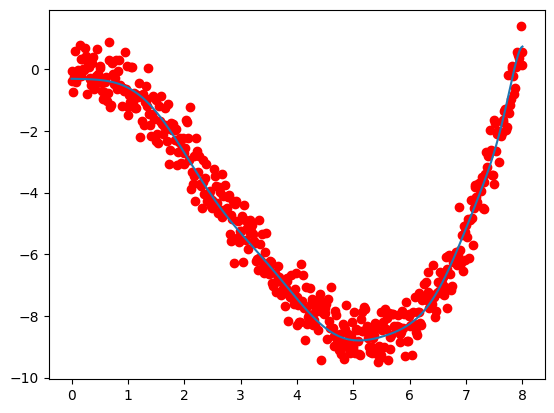

In [ ]:
# creando un objeto para la regresión polinómica

from sklearn.preprocessing import PolynomialFeatures
poly_regressor = PolynomialFeatures(degree=n)
poly_features = poly_regressor.fit_transform(x_data.reshape(-1,1))
# como un polinomio sigue haciendo parte de los modelos de regresión linea, empleamos la clase LinealRegression
model = LinearRegression()
model.fit(poly_features, y_data)

y_pred = model.predict(poly_features)

plt.scatter(x_data, y_data2, c='r')
plt.plot(x_data, y_pred)




RMSE (Polynomial Regression): 0.5364
MAE (Polynomial Regression): 0.4280
MAPE (Polynomial Regression): 67.2068%
R2 (Polynomial Regression): 0.9703


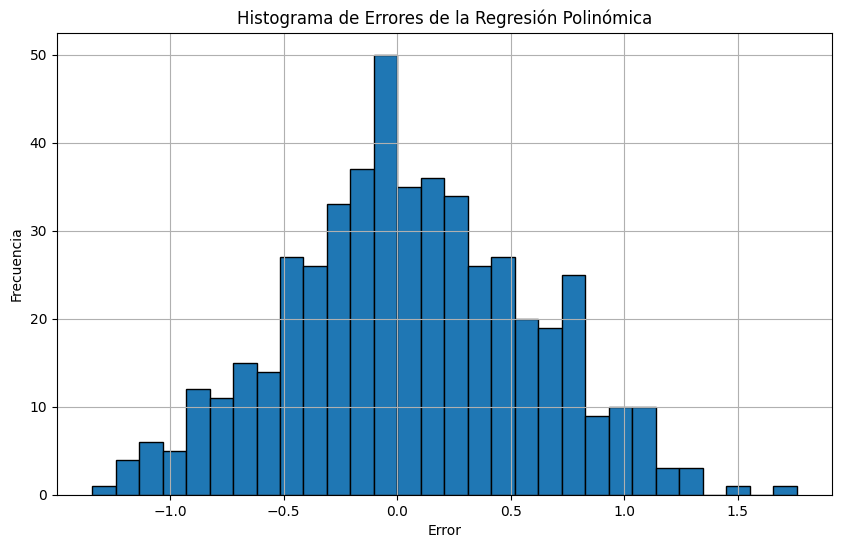

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Actual values (noisy data) and predicted values from the polynomial model
y_true_poly = y_data2
y_pred_poly = y_pred

# 1. Calculate RMSE (Root Mean Squared Error)
rmse_poly = np.sqrt(mean_squared_error(y_true_poly, y_pred_poly))
print(f"RMSE (Polynomial Regression): {rmse_poly:.4f}")

# 2. Calculate MAE (Mean Absolute Error)
mae_poly = mean_absolute_error(y_true_poly, y_pred_poly)
print(f"MAE (Polynomial Regression): {mae_poly:.4f}")

# 3. Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Handle division by zero for y_true values close to zero
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100

mape_poly = mean_absolute_percentage_error(y_true_poly, y_pred_poly)
print(f"MAPE (Polynomial Regression): {mape_poly:.4f}%")

# 4. Calculate R2 (Coefficient of Determination)
r2_poly = r2_score(y_true_poly, y_pred_poly)
print(f"R2 (Polynomial Regression): {r2_poly:.4f}")

# 5. Histogram of Errors
errors_poly = y_true_poly - y_pred_poly

plt.figure(figsize=(10, 6))
plt.hist(errors_poly, bins=30, edgecolor='black')
plt.title('Histograma de Errores de la Regresión Polinómica')
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define the range of degrees to test (from 1 to n, where n is defined in the previous cell)
degrees = range(1, n + 1)

# List to store metrics for each degree
metrics_results = []

# Custom MAPE function (re-defined for self-containment)
def mean_absolute_percentage_error(y_true, y_pred):
    # Handle division by zero for y_true values close to zero
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100

for degree in degrees:
    # 1. Create polynomial features
    poly_regressor = PolynomialFeatures(degree=degree)
    poly_features = poly_regressor.fit_transform(x_data.reshape(-1, 1))

    # 2. Create and fit Linear Regression model
    model = LinearRegression()
    model.fit(poly_features, y_data2) # Fit to noisy data

    # 3. Make predictions
    y_pred = model.predict(poly_features)

    # 4. Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_data2, y_pred))
    mae = mean_absolute_error(y_data2, y_pred)
    mape = mean_absolute_percentage_error(y_data2, y_pred)
    r2 = r2_score(y_data2, y_pred)

    # 5. Store metrics
    metrics_results.append({
        'Degree': degree,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    })

# Convert results to a pandas DataFrame
metrics_df = pd.DataFrame(metrics_results)

# Display the table
print("Métricas de Regresión Polinómica por Grado:")
print(metrics_df)

# Optionally, visualize the best model (e.g., the one with the highest R2 or lowest RMSE)
# For simplicity, we can plot the last one calculated in the loop, or pick one programmatically.
# For now, let's assume the user might want to re-run the previous cell with specific 'n' for visualization.


Métricas de Regresión Polinómica por Grado:
    Degree      RMSE       MAE        MAPE        R2
0        1  2.683483  2.218740  459.689426  0.256497
1        2  1.316911  1.099971  311.977539  0.820940
2        3  0.520016  0.419460   47.942962  0.972080
3        4  0.519680  0.418262   48.732546  0.972116
4        5  0.519392  0.418365   49.499079  0.972147
5        6  0.519384  0.418309   49.400810  0.972148
6        7  0.518984  0.417503   49.510022  0.972190
7        8  0.518682  0.417061   48.608377  0.972223
8        9  0.518672  0.417117   48.760747  0.972224
9       10  0.518672  0.417118   48.789523  0.972224
10      11  0.517755  0.415253   47.665517  0.972322
11      12  0.518166  0.416000   48.895314  0.972278
12      13  0.518269  0.416345   49.901229  0.972267
13      14  0.518321  0.416423   49.864110  0.972261
14      15  0.528562  0.423976   64.285283  0.971155
15      16  0.555264  0.445311   83.051408  0.968167
16      17  0.779415  0.623633  177.827962  0.937278
17

In [ ]:
print("\nMejor desempeño por métrica:")

# Mejor RMSE
min_rmse_row = metrics_df.loc[metrics_df['RMSE'].idxmin()]
print(f"  RMSE óptimo: {min_rmse_row['RMSE']:.4f} en el Grado {int(min_rmse_row['Degree'])}")

# Mejor MAE
min_mae_row = metrics_df.loc[metrics_df['MAE'].idxmin()]
print(f"  MAE óptimo: {min_mae_row['MAE']:.4f} en el Grado {int(min_mae_row['Degree'])}")

# Mejor MAPE
min_mape_row = metrics_df.loc[metrics_df['MAPE'].idxmin()]
print(f"  MAPE óptimo: {min_mape_row['MAPE']:.4f}% en el Grado {int(min_mape_row['Degree'])}")

# Mejor R2
max_r2_row = metrics_df.loc[metrics_df['R2'].idxmax()]
print(f"  R2 óptimo: {max_r2_row['R2']:.4f} en el Grado {int(max_r2_row['Degree'])}")


Mejor desempeño por métrica:
  RMSE óptimo: 0.5178 en el Grado 11
  MAE óptimo: 0.4153 en el Grado 11
  MAPE óptimo: 47.6655% en el Grado 11
  R2 óptimo: 0.9723 en el Grado 11
